In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ipythonx/mvtec-ad/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/000_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/003_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/004_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/005_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/001_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/006_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/008_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/007_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/002_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/009_mask.png
/kaggle/in

In [2]:
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

In [4]:
class IndustrialClassifier:
    def __init__(self, method='boosting'):
        if method == 'boosting':
            self.model = AdaBoostClassifier(n_estimators=100, random_state=42)
        else:
            self.model = GaussianNB()

        self.is_trained = False

    def train(self, X, y):
        if len(X) == 0:
            print("No data for training!")
            return

        self.model.fit(X, y)
        self.is_trained = True
        print(f"Model trained on {len(X)} samples.")

    def predict(self, features):
        if not self.is_trained:
            raise Exception("Model not trained!")

        return self.model.predict([features])[0]

    def predict_label(self, features):
        if not self.is_trained:
            raise Exception("Model not trained!")
        
        pred = self.predict(features)
        return "Defective" if pred == 1 else "Non-Defective"

    def evaluate(self, X_test, y_test):
        if not self.is_trained:
            raise Exception("Model not trained!")
        
        y_pred = self.model.predict(X_test)

        print("\n=== Classification Report ===")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(classification_report(y_test, y_pred, target_names=['Good', 'Defective']))

In [10]:
import os
import cv2
import numpy as np


DATASET_PATH = "/kaggle/input/datasets/ipythonx/mvtec-ad/bottle/test"

# Feature Extraction 
def extract_features(img):
    img = cv2.resize(img, (128, 128))
    
    # grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # basic features
    mean = np.mean(gray)
    std = np.std(gray)
    
    # edges
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges) / (128 * 128)
    
    return [mean, std, edge_density]


# Load the data
X = []
y = []

for category in os.listdir(DATASET_PATH):
    category_path = os.path.join(DATASET_PATH, category)

    if not os.path.isdir(category_path):
        continue
    
    # label
    label = 0 if category == "good" else 1
    
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        features = extract_features(img)
        
        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset loaded!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded!
X shape: (83, 3)
y shape: (83,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf_model = IndustrialClassifier(method='boosting')

clf_model.train(X_train, y_train)
clf_model.evaluate(X_test, y_test)

Model trained on 66 samples.

=== Classification Report ===
Accuracy: 0.8235
              precision    recall  f1-score   support

        Good       0.67      0.50      0.57         4
   Defective       0.86      0.92      0.89        13

    accuracy                           0.82        17
   macro avg       0.76      0.71      0.73        17
weighted avg       0.81      0.82      0.81        17



In [12]:
import joblib

joblib.dump(clf_model.model, "/kaggle/working/model.pkl")

['/kaggle/working/model.pkl']

In [9]:
# Just for illustration
print(os.listdir("/kaggle/input"))
print(os.listdir("/kaggle/input/datasets"))
print(os.listdir("/kaggle/input/datasets/ipythonx/mvtec-ad"))

['datasets']
['ipythonx']
['wood', 'screw', 'metal_nut', 'capsule', 'readme.txt', 'hazelnut', 'carpet', 'pill', 'license.txt', 'grid', 'zipper', 'transistor', 'tile', 'leather', 'toothbrush', 'bottle', 'cable']


In [37]:
img_path = "/kaggle/input/datasets/ipythonx/mvtec-ad/bottle/test/good/006.png"

img = cv2.imread(img_path)

features = extract_features(img)

In [38]:
prediction = clf_model.predict_label(features)
print("Prediction:", prediction)

Prediction: Non-Defective


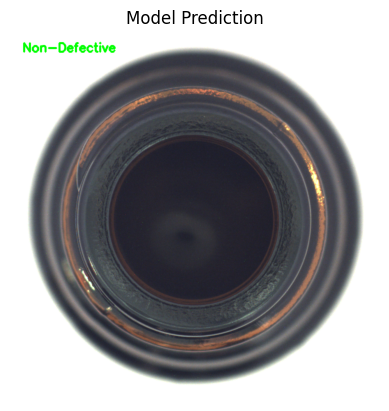

In [39]:
import matplotlib.pyplot as plt

color = (0, 255, 0) if label == "Non-Defective" else (255, 0, 0)

display_img = img.copy()
cv2.putText(display_img, label, (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)

plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Model Prediction")
plt.show()